# Laboratorio #1 - Entrenamiento de Redes Neuronales (MLP)

**Curso:** CC3092 - Deep Learning y Sistemas Inteligentes

**Dataset:** California Housing Prices (regresión) — `sklearn.datasets.fetch_california_housing`

**Repositorio:** https://github.com/anthonylouschwank/Lab1-DeepLearning

Este notebook cubre: carga y preparación de datos, investigación de capas/optimizadores de PyTorch, definición del modelo MLP, entrenamiento con búsqueda de hiperparámetros (10+ iteraciones) y evaluación final sobre el conjunto de test.

## 1. Importación de librerías y carga del dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.datasets import fetch_california_housing

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print("torch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

torch: 2.13.0+cpu
CUDA disponible: False


Usamos la versión de `scikit-learn` del dataset (`fetch_california_housing`), que es equivalente en contenido al dataset de Kaggle pero ya viene limpio (sin nulos) y sin la columna categórica `ocean_proximity`. Cargamos los datos en un `DataFrame` de pandas para facilitar la exploración.

In [2]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame.copy()
df = df.rename(columns={"MedHouseVal": "median_house_value"})

print("Shape:", df.shape)
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,median_house_value
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Exploración de datos (EDA)

### Diccionario de variables

| Variable | Descripción |
|---|---|
| `MedInc` | Ingreso medio del distrito censal (en decenas de miles de USD) |
| `HouseAge` | Edad mediana de las viviendas del distrito (años) |
| `AveRooms` | Número promedio de habitaciones por vivienda |
| `AveBedrms` | Número promedio de dormitorios por vivienda |
| `Population` | Población total del distrito censal |
| `AveOccup` | Número promedio de ocupantes por vivienda |
| `Latitude` | Latitud geográfica del distrito |
| `Longitude` | Longitud geográfica del distrito |
| `median_house_value` | **Target.** Valor mediano de las viviendas del distrito (en cientos de miles de USD) |

Cada fila representa un **distrito censal (block group)** de California, no una vivienda individual — las variables `AveRooms`, `AveBedrms` y `AveOccup` son promedios agregados a nivel de distrito.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MedInc              20640 non-null  float64
 1   HouseAge            20640 non-null  float64
 2   AveRooms            20640 non-null  float64
 3   AveBedrms           20640 non-null  float64
 4   Population          20640 non-null  float64
 5   AveOccup            20640 non-null  float64
 6   Latitude            20640 non-null  float64
 7   Longitude           20640 non-null  float64
 8   median_house_value  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


**¿Cuántas observaciones y cuántas variables tiene el dataset?**

El dataset tiene **20,640 observaciones** (distritos censales) y **9 variables**: 8 features numéricas (`MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, `Longitude`) más la variable objetivo `median_house_value`.

**¿Qué representa cada variable (feature) y cuál es la variable objetivo (target)?**

Ver el diccionario de variables arriba. El target es `median_house_value`, el valor mediano de las viviendas del distrito.

### Valores nulos y duplicados

In [5]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print("\nTotal de filas duplicadas:", df.duplicated().sum())

Valores nulos por columna:
MedInc                0
HouseAge              0
AveRooms              0
AveBedrms             0
Population            0
AveOccup              0
Latitude              0
Longitude             0
median_house_value    0
dtype: int64



Total de filas duplicadas: 0


### Valores atípicos (outliers)

Revisamos la distribución de cada variable numérica con boxplots y calculamos cuántos valores caen fuera del rango intercuartílico (IQR) para dimensionar el problema. También revisamos si el target está *censurado* (capado en un valor máximo), un problema conocido de este dataset.

C:\Users\antho\AppData\Local\Temp\ipykernel_18652\3897830295.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col], vert=True)
C:\Users\antho\AppData\Local\Temp\ipykernel_18652\3897830295.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col], vert=True)
C:\Users\antho\AppData\Local\Temp\ipykernel_18652\3897830295.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col], vert=True)
C:\Users\antho\AppData\Local\Temp\ipykernel_18652\3897830295.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.

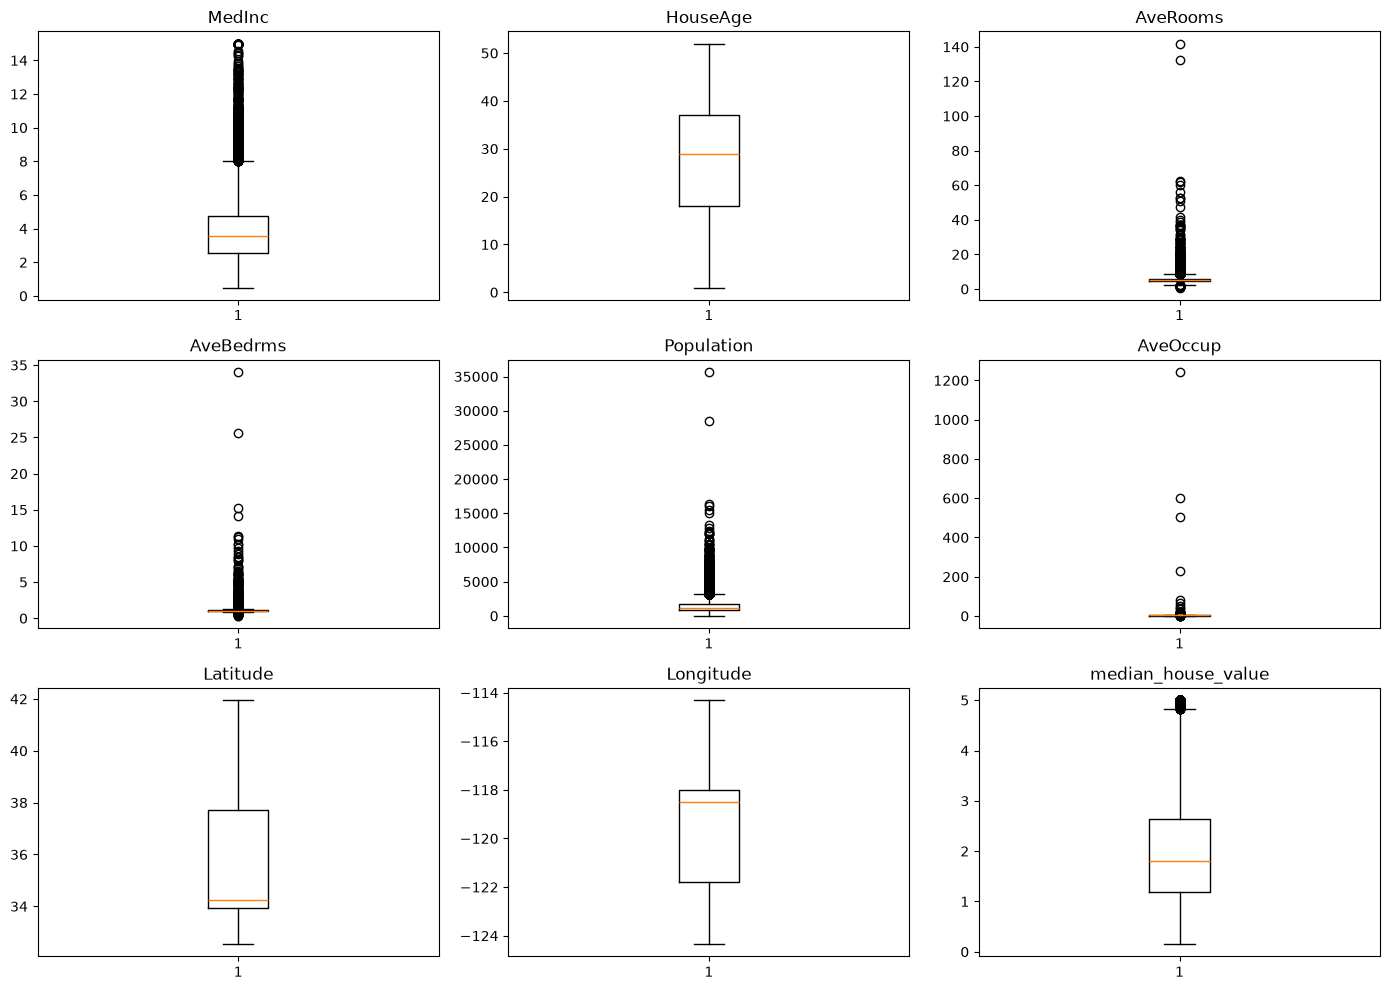

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flatten(), df.columns):
    ax.boxplot(df[col], vert=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [7]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_counts = df.drop(columns="median_house_value").apply(iqr_outlier_count).sort_values(ascending=False)
print("Outliers por variable (regla IQR 1.5x):")
print(outlier_counts)

capped = (df["median_house_value"] == df["median_house_value"].max()).sum()
print(f"\nObservaciones con target en el valor máximo ({df['median_house_value'].max()}): {capped} ({capped / len(df):.2%})")

Outliers por variable (regla IQR 1.5x):
AveBedrms     1424
Population    1196
AveOccup       711
MedInc         681
AveRooms       511
HouseAge         0
Latitude         0
Longitude        0
dtype: int64

Observaciones con target en el valor máximo (5.00001): 965 (4.68%)


**¿Hay valores nulos, duplicados o atípicos (outliers)? ¿Cómo los trató?**

- **Nulos:** no hay ningún valor nulo en las 9 columnas.
- **Duplicados:** no hay filas duplicadas (0 de 20,640).
- **Outliers:** sí existen, principalmente en `AveBedrms` (1424), `Population` (1196), `AveOccup` (711), `MedInc` (681) y `AveRooms` (511), según la regla de 1.5×IQR. Corresponden a distritos con densidades de ocupación o ingresos poco comunes (p. ej. zonas turísticas o de muy alta densidad), no a errores de captura. Adicionalmente, el target `median_house_value` está **censurado**: 965 observaciones (4.68%) están topadas exactamente en el valor máximo (5.00001, equivalente a $500,001), un artefacto conocido de este dataset.

  **Tratamiento:** no eliminamos estos outliers. Son valores reales de distritos censales, no errores; eliminarlos reduciría la representatividad del dataset y el tamaño de muestra. En su lugar, mitigamos su efecto sobre el entrenamiento escalando las variables numéricas (ver abajo). El escalado con `StandardScaler` reduce la influencia desproporcionada de outliers en la magnitud del gradiente, aunque no elimina el sesgo introducido por la censura del target (se discute en la sección de análisis final).

**¿Qué variables son numéricas y cuáles categóricas? ¿Cómo codificó las categóricas?**

Las 8 features (y el target) son **todas numéricas continuas**. La versión de `scikit-learn` del dataset no incluye la variable categórica `ocean_proximity` que sí trae el CSV de Kaggle; al no haber variables categóricas, no fue necesario aplicar ninguna codificación (one-hot, ordinal, etc.).

**¿Fue necesario normalizar o escalar las variables numéricas?**

Sí. Las variables tienen escalas muy distintas (p. ej. `Population` está en cientos/miles mientras `Latitude`/`Longitude` están en decenas, y `AveOccup` en unidades). Un MLP entrenado con descenso de gradiente converge más rápido y de forma más estable cuando las features están en rangos comparables, y evita que variables con magnitudes grandes dominen la función de pérdida. Aplicaremos `StandardScaler` (media 0, desviación estándar 1), **ajustado únicamente sobre el conjunto de entrenamiento** y luego aplicado a validación y test, para no filtrar información del test hacia el proceso de entrenamiento.

### División en entrenamiento, validación y prueba

Dividimos el dataset en tres conjuntos: **70% entrenamiento / 15% validación / 15% prueba (test)**. El conjunto de test se separa primero y se deja completamente al margen: no se usa para entrenar, ni para elegir arquitectura, ni para ajustar hiperparámetros — solo se usa **una vez**, al final, para evaluar el modelo ya seleccionado. El conjunto de validación es el que se usa durante la búsqueda de hiperparámetros (sección 4) para comparar iteraciones y elegir la mejor configuración.

In [8]:
from sklearn.model_selection import train_test_split

FEATURE_COLS = [c for c in df.columns if c != "median_house_value"]
TARGET_COL = "median_house_value"

# 1) separamos test (15%) primero, y lo dejamos intacto hasta la evaluación final
train_val_df, test_df = train_test_split(df, test_size=0.15, random_state=RANDOM_STATE)

# 2) del 85% restante, separamos validación (15% del total => ~17.65% del restante)
train_df, val_df = train_test_split(train_val_df, test_size=0.15 / 0.85, random_state=RANDOM_STATE)

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_val, y_val = val_df[FEATURE_COLS], val_df[TARGET_COL]
X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET_COL]

print(f"Train: {X_train.shape[0]} ({X_train.shape[0] / len(df):.1%})")
print(f"Val:   {X_val.shape[0]} ({X_val.shape[0] / len(df):.1%})")
print(f"Test:  {X_test.shape[0]} ({X_test.shape[0] / len(df):.1%})")

Train: 14448 (70.0%)
Val:   3096 (15.0%)
Test:  3096 (15.0%)


### Escalado de features

Ajustamos (`fit`) el `StandardScaler` **únicamente sobre `X_train`**, y luego lo aplicamos (`transform`) a validación y test. Esto evita que estadísticas del conjunto de validación/test (media, desviación estándar) se filtren hacia el entrenamiento, respetando la regla de que el test no debe influir en ninguna decisión.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Media por feature (train escalado, debe ser ~0):")
print(X_train_scaled.mean(axis=0).round(3))
print("\nDesviación estándar por feature (train escalado, debe ser ~1):")
print(X_train_scaled.std(axis=0).round(3))

Media por feature (train escalado, debe ser ~0):
[-0.  0. -0.  0. -0. -0. -0.  0.]

Desviación estándar por feature (train escalado, debe ser ~1):
[1. 1. 1. 1. 1. 1. 1. 1.]


### Conversión a tensores de PyTorch

Convertimos los arreglos de NumPy a `torch.Tensor` (tipo `float32`), listos para usarse en el entrenamiento del MLP en la sección 4. El target se deja como columna (`shape (N, 1)`) para que coincida con la salida de la capa final del MLP.

In [10]:
def to_tensor(X, y):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y.to_numpy(), dtype=torch.float32).view(-1, 1)
    return X_t, y_t

X_train_t, y_train_t = to_tensor(X_train_scaled, y_train)
X_val_t, y_val_t = to_tensor(X_val_scaled, y_val)
X_test_t, y_test_t = to_tensor(X_test_scaled, y_test)

print("X_train_t:", X_train_t.shape, "y_train_t:", y_train_t.shape)
print("X_val_t:  ", X_val_t.shape, "y_val_t:  ", y_val_t.shape)
print("X_test_t: ", X_test_t.shape, "y_test_t: ", y_test_t.shape)

X_train_t: torch.Size([14448, 8]) y_train_t: torch.Size([14448, 1])
X_val_t:   torch.Size([3096, 8]) y_val_t:   torch.Size([3096, 1])
X_test_t:  torch.Size([3096, 8]) y_test_t:  torch.Size([3096, 1])


## 3. Investigación: capas y optimizadores de PyTorch para el MLP

Antes de definir la arquitectura, documentamos las capas de `torch.nn`, las funciones de pérdida y los optimizadores de `torch.optim` que usaremos para construir y entrenar el MLP de regresión.

### 3.1 Capas de `torch.nn`

**`nn.Linear(in_features, out_features, bias=True)`**
Aplica una transformación lineal `y = xW^T + b`. Es la capa "fully connected" que conecta cada neurona de entrada con cada neurona de salida; es el bloque básico de un MLP. `in_features` y `out_features` definen el tamaño de entrada y salida de la capa; `bias` controla si se aprende un término de sesgo `b`.

**Funciones de activación**

- **`nn.ReLU()`** — `f(x) = max(0, x)`. Introduce no linealidad de forma barata computacionalmente y evita la saturación de gradientes para valores positivos, pero puede "matar" neuronas (gradiente 0 para entradas negativas, problema de "dying ReLU").
- **`nn.LeakyReLU(negative_slope=0.01)`** — igual que ReLU pero permite un gradiente pequeño y distinto de cero para `x < 0` (`f(x) = x` si `x>0`, `f(x) = negative_slope * x` si `x<=0`). Mitiga el problema de "dying ReLU" manteniendo casi las mismas ventajas.
- **`nn.Tanh()`** — `f(x) = tanh(x)`, salida acotada en `(-1, 1)`, centrada en 0. Útil cuando se quiere una salida simétrica, pero satura para valores grandes de `|x|`, lo que puede ralentizar el aprendizaje en redes profundas (vanishing gradient).

**`nn.Dropout(p=0.5)`**
Durante entrenamiento, desactiva aleatoriamente una fracción `p` de las neuronas de la capa anterior en cada forward pass, forzando a la red a no depender de neuronas específicas. Es una técnica de regularización que reduce el overfitting. Durante evaluación (`model.eval()`) se desactiva automáticamente y se escalan las activaciones.

**`nn.BatchNorm1d(num_features)`**
Normaliza (media 0, varianza 1) las activaciones de cada mini-batch a lo largo de la dimensión de features, y luego aplica una transformación afín aprendible (`gamma`, `beta`). Acelera y estabiliza el entrenamiento al reducir el "internal covariate shift", permite usar learning rates más altos y tiene un leve efecto regularizador. `num_features` debe coincidir con el número de salidas de la capa anterior.

### 3.2 Funciones de pérdida para regresión

- **`nn.MSELoss()`** — error cuadrático medio: `mean((y_pred - y_true)^2)`. Penaliza fuertemente los errores grandes (al elevarlos al cuadrado), por lo que es sensible a outliers. Es la pérdida más común para regresión.
- **`nn.L1Loss()`** — error absoluto medio: `mean(|y_pred - y_true|)`. Penaliza todos los errores de forma lineal, por lo que es más robusta a outliers que MSE, pero su gradiente es constante (no decrece cerca del óptimo), lo que puede dificultar la convergencia fina.
- **`nn.SmoothL1Loss()`** (Huber loss) — combina ambas: se comporta como MSE para errores pequeños (`|error| < beta`) y como L1 para errores grandes. Ofrece un balance entre sensibilidad a outliers (como L1) y gradiente suave cerca del óptimo (como MSE).

### 3.3 Optimizadores de `torch.optim`

Todos los optimizadores de `torch.optim` comparten dos parámetros clave:

- **`lr` (learning rate):** tamaño del paso con el que se actualizan los pesos en cada iteración, en la dirección opuesta al gradiente. Un `lr` muy alto puede hacer que el entrenamiento diverja u oscile sin converger; uno muy bajo hace que el entrenamiento sea muy lento o se quede atascado en mínimos locales/planicies.
- **`weight_decay`:** aplica regularización L2, añadiendo un término `weight_decay * peso` a la actualización de cada parámetro en cada paso. Penaliza pesos grandes, ayudando a prevenir overfitting al favorecer soluciones más simples.

**`optim.SGD(params, lr, momentum=0, weight_decay=0)`**
Descenso de gradiente estocástico: actualiza los pesos moviéndolos en la dirección negativa del gradiente calculado sobre cada mini-batch, `w = w - lr * grad`. Es el optimizador más simple y con menos "memoria" (no adapta el learning rate por parámetro). Con `momentum > 0` acumula una fracción del gradiente anterior para acelerar la convergencia y amortiguar oscilaciones. Suele requerir más iteraciones y un ajuste más cuidadoso de `lr` que los optimizadores adaptativos, pero a menudo generaliza mejor cuando se afina bien.

**`optim.Adam(params, lr, betas=(0.9, 0.999), weight_decay=0)`**
Combina momentum (media móvil del gradiente, `beta1`) con una tasa de aprendizaje adaptativa por parámetro basada en la media móvil del gradiente al cuadrado (`beta2`), similar a RMSprop. Es robusto a la elección de `lr` y suele converger rápido con poco ajuste, por lo que es el optimizador por defecto más usado en la práctica. Su regularización L2 vía `weight_decay` se calcula sobre el gradiente antes de la adaptación (a diferencia de `AdamW`, que la desacopla), lo cual puede hacerla menos efectiva que en SGD.

**`optim.RMSprop(params, lr, alpha=0.99, weight_decay=0)`**
Adapta el learning rate de cada parámetro dividiendo el gradiente entre la raíz de una media móvil exponencial de los gradientes al cuadrado. Esto evita que parámetros con gradientes históricamente grandes sigan dando pasos grandes, y ayuda en problemas con gradientes muy dispersos o de escalas distintas. Fue uno de los predecesores directos de Adam (que añade el término de momentum); en la práctica Adam suele igualar o superar a RMSprop, pero RMSprop puede ser preferible en tareas con datos no estacionarios (p. ej. RL) por ser más "reactivo".

**Comparación:** SGD es el más simple pero el que requiere más ajuste manual de `lr`/`momentum`; Adam y RMSprop adaptan el `lr` por parámetro y convergen más rápido con menos ajuste, siendo Adam generalmente la opción por defecto más estable. Para este laboratorio probaremos los tres como parte de la búsqueda de hiperparámetros.

In [11]:
# Ejemplo rápido de instanciación de las capas y optimizadores investigados
example_layer = nn.Linear(in_features=8, out_features=16)
example_activations = {"ReLU": nn.ReLU(), "LeakyReLU": nn.LeakyReLU(0.01), "Tanh": nn.Tanh()}
example_dropout = nn.Dropout(p=0.3)
example_bn = nn.BatchNorm1d(num_features=16)

example_losses = {"MSE": nn.MSELoss(), "L1": nn.L1Loss(), "SmoothL1": nn.SmoothL1Loss()}

dummy_params = [torch.nn.Parameter(torch.randn(4, 4))]
example_optimizers = {
    "SGD": torch.optim.SGD(dummy_params, lr=0.01, momentum=0.9, weight_decay=1e-4),
    "Adam": torch.optim.Adam(dummy_params, lr=0.001, weight_decay=1e-4),
    "RMSprop": torch.optim.RMSprop(dummy_params, lr=0.001, weight_decay=1e-4),
}

print(example_layer)
print(example_activations)
print(example_dropout, example_bn)
print(example_losses)
for name, opt in example_optimizers.items():
    print(name, "->", opt)

Linear(in_features=8, out_features=16, bias=True)
{'ReLU': ReLU(), 'LeakyReLU': LeakyReLU(negative_slope=0.01), 'Tanh': Tanh()}
Dropout(p=0.3, inplace=False) BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
{'MSE': MSELoss(), 'L1': L1Loss(), 'SmoothL1': SmoothL1Loss()}
SGD -> SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0.0001
)
Adam -> Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
RMSprop -> RMSprop (
Parameter Group 0
    alpha: 0.99
    capturable: False
    centered: False
    differentiable: False
    eps: 1e-08
    foreach: None
    lr: 0.001
    maximize: False
    momentum: 0
    weig